<a href="https://colab.research.google.com/github/maulikcmr05/Deep-Learning/blob/main/E1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


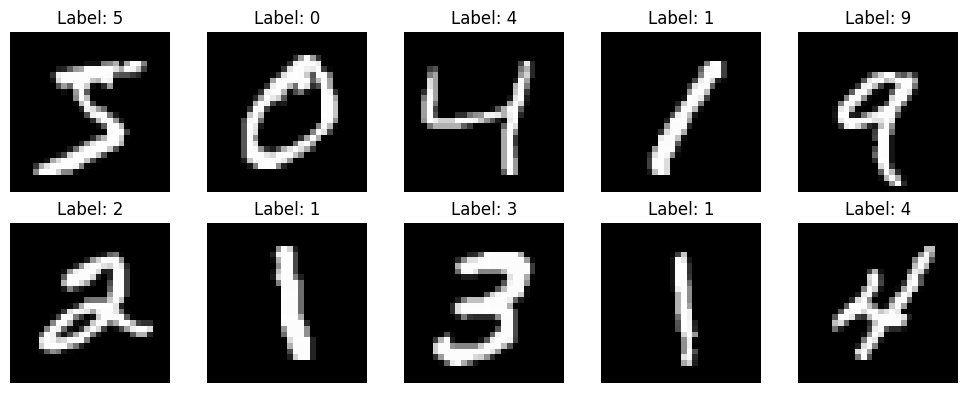

In [8]:
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i], cmap="gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Normalize pixel values to the range 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [10]:
model_mnist = keras.Sequential([
  layers.Input(shape=(28, 28)),
  layers.Flatten(),
  layers.Dense(256, activation="relu"),
  layers.Dense(256, activation="relu"),
  layers.Dense(10, activation="softmax")
])
model_mnist.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_mnist.compile(
  optimizer="adam",
  loss="sparse_categorical_crossentropy",
  metrics=["accuracy"]
)

In [12]:
history_mnist = model_mnist.fit(
x_train,
y_train,
epochs=10,
batch_size=128,
validation_split=0.1,
verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9216 - loss: 0.2761 - val_accuracy: 0.9655 - val_loss: 0.1236
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9685 - loss: 0.1038 - val_accuracy: 0.9757 - val_loss: 0.0795
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9801 - loss: 0.0646 - val_accuracy: 0.9757 - val_loss: 0.0794
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9852 - loss: 0.0462 - val_accuracy: 0.9768 - val_loss: 0.0745
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9886 - loss: 0.0359 - val_accuracy: 0.9778 - val_loss: 0.0768
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.9793 - val_loss: 0.0766
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9927 - loss: 0.0230 - val_accuracy: 0.9808 - val_loss: 0.0673
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accu

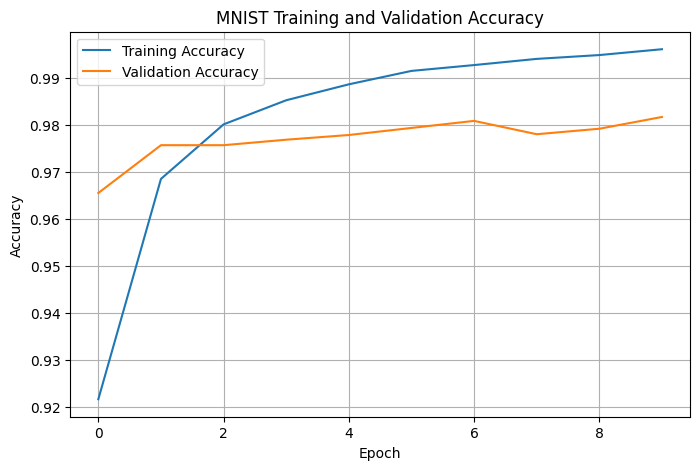

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_mnist.history["accuracy"], label="Training Accuracy")
plt.plot(history_mnist.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

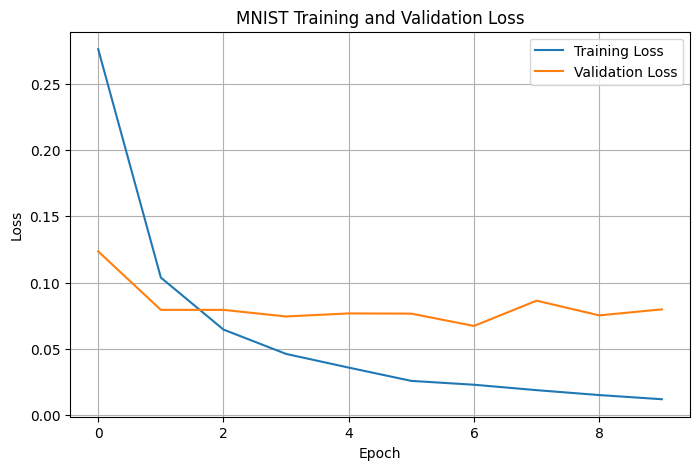

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_mnist.history["loss"], label="Training Loss")
plt.plot(history_mnist.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
test_loss, test_accuracy = model_mnist.evaluate(
x_test,
y_test,
verbose=0
)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4%}")

Test Loss : 0.0814
Test Accuracy : 98.0700%


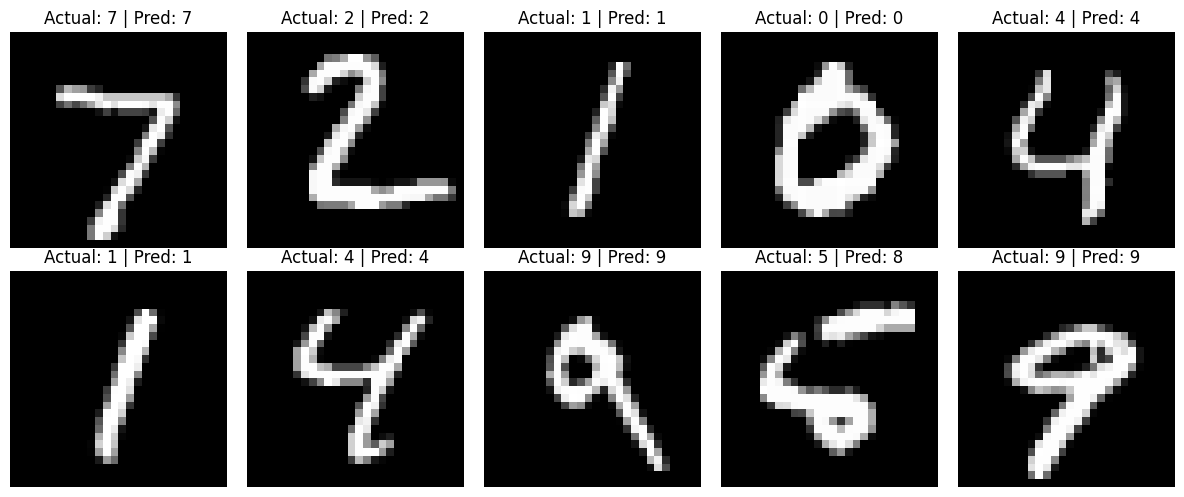

Actual labels : [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 8 9]


In [16]:
# Select 10 test images
sample_images = x_test[:10]
sample_labels = y_test[:10]
predicted_probabilities = model_mnist.predict(sample_images, verbose=0)
predicted_labels = np.argmax(predicted_probabilities, axis=1)
plt.figure(figsize=(12, 5))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(sample_images[i], cmap="gray")
  plt.title(f"Actual: {sample_labels[i]} | Pred: {predicted_labels[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()
print("Actual labels :", sample_labels)
print("Predicted labels:", predicted_labels)

Actual digit: 7
Predicted digit: 7
Confidence: 0.999989


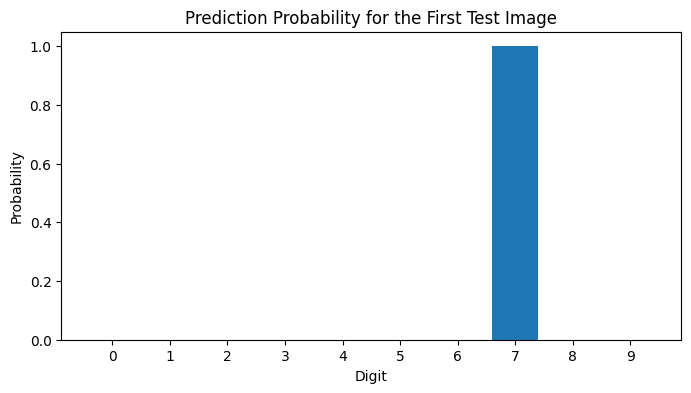

In [17]:
# Display the prediction probabilities for the first test image
first_prediction = predicted_probabilities[0]
print("Actual digit:", sample_labels[0])
print("Predicted digit:", predicted_labels[0])
print("Confidence:", first_prediction[predicted_labels[0]])
plt.figure(figsize=(8, 4))
plt.bar(range(10), first_prediction)
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Prediction Probability for the First Test Image")
plt.show()